In [34]:
from typing import NamedTuple
import jax
import jax.numpy as jnp
from jax import Array

ACTIONS = jnp.array([
    [-1,  0],  # up    (row - 1)
    [ 1,  0],  # down  (row + 1)
    [ 0, -1],  # left  (col - 1)
    [ 0,  1],  # right (col + 1)
], dtype=jnp.int32)

# 0=white, 1=red (agent), 2=green (goal), 3=black (moving block)
COLOR_MAP = jnp.array(
    [
        [255, 255, 255],  # white
        [255,   0,   0],  # red
        [  0, 255,   0],  # green
        [  0,   0,   0],  # black
    ],
    dtype=jnp.uint8
)

class EnvState(NamedTuple):
    agent_pos: Array   # int32[2]  (row, col)
    goal_pos:  Array   # int32[2]
    key:       Array   # PRNGKey
    block_pos: Array   # int32[2]  moving black block (row fixed, col moves)
    block_dir: Array   # int32 scalar in {-1, +1} (horizontal direction)

class SimpleGridWorld:
    """
    Coordinate note: 'up' reduces the FIRST coordinate (row).
    So 'top' == row 0, 'bottom' == row dim-1. We therefore fix:
      - agent at bottom row  (row = dim-1)
      - goal  at top row     (row = 0)
      - block on the middle row (row = dim//2), moving left/right.
    """
    def __init__(self, dim: int, tile: int = 8):
        self.dim = int(dim)
        self.tile = int(tile)

    def init(self, key: Array) -> EnvState:
        dim = self.dim
        # sample columns for agent & goal; block starts mid-row with random column and dir
        key, k_agent_c, k_goal_c, k_block_c, k_dir = jax.random.split(key, 5)

        agent_col = jax.random.randint(k_agent_c, (), 0, dim, dtype=jnp.int32)
        goal_col  = jax.random.randint(k_goal_c,  (), 0, dim, dtype=jnp.int32)
        mid_row   = jnp.array(dim // 2, dtype=jnp.int32)  # in-between top and bottom

        block_col = jax.random.randint(k_block_c, (), 0, dim, dtype=jnp.int32)
        block_dir = jax.random.choice(k_dir, jnp.array([-1, 1], dtype=jnp.int32))  # ±1

        agent = jnp.stack([jnp.int32(dim - 1), agent_col])  # bottom row
        goal  = jnp.stack([jnp.int32(0),        goal_col])  # top row
        block = jnp.stack([mid_row, block_col])

        return EnvState(agent, goal, key, block, block_dir)

    def reset(self, state: EnvState) -> EnvState:
        return self.init(state.key)

    def get_grid(self, state: EnvState) -> Array:
        dim = self.dim
        grid = jnp.zeros((dim, dim), jnp.int32)

        ax, ay = state.agent_pos
        gx, gy = state.goal_pos
        bx, by = state.block_pos

        # draw block first so agent/goal take visual precedence if overlap ever occurs
        grid = grid.at[bx, by].set(3)  # black
        grid = grid.at[ax, ay].set(1)  # red
        grid = grid.at[gx, gy].set(2)  # green
        return grid

    def _move_block(self, block_pos: Array, block_dir: Array) -> tuple[Array, Array]:
        """Horizontal (left/right) movement on a fixed row with edge bounces."""
        dim = self.dim
        row, col = block_pos
        new_col = col + block_dir
        bounced = (new_col < 0) | (new_col >= dim)
        next_dir = jnp.where(bounced, -block_dir, block_dir)
        new_col = jnp.clip(new_col, 0, dim - 1)
        return jnp.stack([row, new_col]), next_dir

    def step(self, state: EnvState, action) -> tuple[EnvState, tuple[Array, Array, Array]]:
        """
        returns: (new_state, (obs, reward, done))

        Extra penalty:
        -2 if the agent overlaps with the block, touches it (attempted move into it),
        or is directly adjacent (top/left/right/bottom) after movement.
        """
        dim = self.dim
        action = jnp.asarray(action, jnp.int32)
        delta  = jnp.take(ACTIONS, action, axis=0, mode="clip")

        # Candidate agent move and check for contact with current block cell
        candidate = jnp.clip(state.agent_pos + delta, 0, dim - 1)
        attempted_contact = jnp.all(candidate == state.block_pos)  # tried to step into block
        new_agent_pos = jnp.where(attempted_contact, state.agent_pos, candidate)

        # Move the block (horizontal bounce)
        new_block_pos, new_block_dir = self._move_block(state.block_pos, state.block_dir)

        # Contact/adjacency AFTER movements (4-neighborhood only; no diagonals)
        overlap_after  = jnp.all(new_agent_pos == new_block_pos)
        manhattan_dist = jnp.abs(new_agent_pos - new_block_pos).sum()
        adjacent_after = (manhattan_dist == 1)

        penalty_mask = attempted_contact | overlap_after | adjacent_after

        done = jnp.all(new_agent_pos == state.goal_pos)

        base_reward = jnp.where(done, jnp.float32(1.0), jnp.float32(-0.01))
        penalty     = jnp.where(penalty_mask, jnp.float32(-0.01), jnp.float32(0.0))
        reward      = base_reward + penalty
        # If you DON'T want to penalize terminal steps, use:
        # reward = base_reward + penalty * (1.0 - done.astype(jnp.float32))

        # Observation BEFORE reset
        pre_reset_state = EnvState(new_agent_pos, state.goal_pos, state.key,
                                new_block_pos, new_block_dir)
        obs = self.get_grid(pre_reset_state)

        # Next state (reset if done)
        key, reset_key = jax.random.split(state.key)
        reset_state = self.init(reset_key)
        next_state = jax.lax.cond(
            done,
            lambda _: reset_state,
            lambda _: EnvState(new_agent_pos, state.goal_pos, key, new_block_pos, new_block_dir),
            operand=None
        )

        return next_state, (obs, reward, done)


    def render(self, state: EnvState) -> Array:
        dim, tile = self.dim, self.tile
        grid = self.get_grid(state)

        def paint_cell(color: int):
            rgb = COLOR_MAP[color]
            return jnp.ones((tile, tile, 3), dtype=jnp.uint8) * rgb

        row_fn = jax.vmap(paint_cell, in_axes=0, out_axes=0)
        tiles  = jax.vmap(row_fn,    in_axes=0, out_axes=0)(grid)

        return tiles.transpose(0, 2, 1, 3, 4).reshape(dim * tile, dim * tile, 3)


In [2]:
# render 
env = SimpleGridWorld(dim=10, tile=8)  # one moving block
batched_init     = jax.vmap(env.init,     in_axes=0)
batched_step     = jax.vmap(lambda s, a: env.step(s, a), in_axes=(0, 0))
batched_get_grid = jax.vmap(env.get_grid, in_axes=0)
batched_render = jax.vmap(env.render, in_axes=0)

In [25]:
# --- Quick random-policy rollout + GIF ---
import numpy as np
import jax
import jax.numpy as jnp
import imageio.v2 as imageio

# How many parallel episodes and how many steps to record
B = 4
T = 64
fps = 8

# Init batch of environments
key = jax.random.PRNGKey(124)
init_keys = jax.random.split(key, B)
states = batched_init(init_keys)

# Rollout: at each step, sample a random action in [0, 4)
def step_random(carry, _):
    states, key = carry
    key, ak = jax.random.split(key)
    actions = jax.random.randint(ak, (B,), minval=0, maxval=ACTIONS.shape[0], dtype=jnp.int32)
    next_states, (_, rew, done) = batched_step(states, actions)
    # Keep the *current* states for rendering (pre-step), like your actor rollout
    return (next_states, key), (states, actions, rew, done)

(_, (cum_states, cum_actions, cum_rew, cum_done)) = jax.lax.scan(
    step_random, (states, key), jnp.arange(T)
)

# Render frames: shape (T, B, H, W, 3)
render_B  = jax.vmap(env.render, in_axes=0)
render_TB = jax.vmap(render_B,    in_axes=0)
frames_tb = np.asarray(render_TB(cum_states))


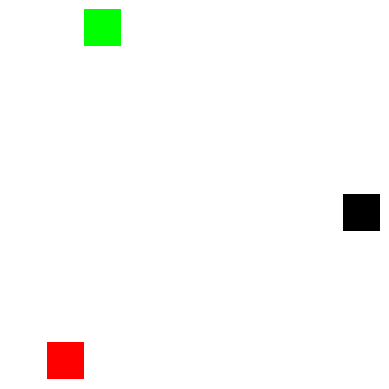

In [4]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots()
im = ax.imshow(frames_tb[0, 0])   # first frame of episode 0
ax.axis('off')

def update(i):
    im.set_data(frames_tb[i, 0])
    return (im,)

ani = animation.FuncAnimation(fig, update, frames=frames_tb.shape[0],
                              interval=1000/fps, blit=True)
HTML(ani.to_jshtml())   # inline, no file writing


In [35]:
from typing import NamedTuple
import jax
import jax.numpy as jnp
from jax import Array
from flax import nnx
import optax

class FeedForwardNN(nnx.Module):
    def __init__(self, din: int, dout: int, *, rngs=nnx.Rngs):
        self.linear1 = nnx.Linear(in_features=din, out_features=64, rngs=rngs)
        self.linear2 = nnx.Linear(in_features=64, out_features=64, rngs=rngs)
        self.linear3 = nnx.Linear(in_features=64, out_features=dout, rngs=rngs)
    
    @nnx.vmap(in_axes=(None,0), out_axes=0)
    def __call__(self, obs: jax.Array):
        activation1 = nnx.relu(self.linear1(obs))
        activation2 = nnx.relu(self.linear2(activation1))
        return self.linear3(activation2)


value_coef   = 0.5
eps_clip     = 0.2
gamma        = 0.95

B = 4096
T = 32
epochs = 30000
k_update_iterations = 5

env = SimpleGridWorld(dim=10, tile=8)  # one moving block
batched_init     = jax.vmap(env.init,     in_axes=0)
batched_step     = jax.vmap(lambda s, a: env.step(s, a), in_axes=(0, 0))
batched_get_grid = jax.vmap(env.get_grid, in_axes=0)
batched_render = jax.vmap(env.render, in_axes=0)

rngs   = nnx.Rngs(0)
actor  = FeedForwardNN(din=env.dim * env.dim, dout=4, rngs=rngs)
critic = FeedForwardNN(din=env.dim * env.dim, dout=1, rngs=rngs)

tx = optax.adam(3e-4)
opt_actor  = nnx.Optimizer(actor,  tx, wrt=nnx.Param)
opt_critic = nnx.Optimizer(critic, tx, wrt=nnx.Param)

# NNX-scan helpers
@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0), reverse=True)
def _rtg_scan(carry, r_t, d_t):
    """
    carry, r_t, d_t are (B,) slices. reverse=True scans from T-1->0.
    """
    carry = r_t + gamma * carry * (1.0 - d_t)  # cut chain at terminals
    return carry, carry

def reward_to_go_with_dones(rewards: jax.Array, dones: jax.Array) -> jax.Array:
    """
    rewards, dones: (T,B) -> rtg: (T,B) with (1-done) gating.
    """
    r = rewards.astype(jnp.float32)
    d = dones.astype(jnp.float32)
    _, rtg = _rtg_scan(jnp.zeros_like(r[0]), r, d)
    return rtg


# training epoch (outer)
@nnx.scan(in_axes=(nnx.Carry, 0), out_axes=(nnx.Carry, 0))
def train_epoch(carry, _):
    actor, critic, opt_actor, opt_critic, rngs = carry

    epoch_key = rngs()
    keys = jax.random.split(epoch_key, B)

    # rollout T steps
    @nnx.scan(in_axes=(nnx.Carry, 0), out_axes=(nnx.Carry, 0))
    def roll(carry, _):
        actor, rngs, states = carry

        obs_t = batched_get_grid(states)                      # s_t
        logits_t = actor(obs_t.reshape(obs_t.shape[0], -1).astype(jnp.float32))
        key = rngs()
        actions = jax.random.categorical(key, logits_t, axis=-1)
        logp_t = jax.nn.log_softmax(logits_t, axis=-1)
        old_lp_t = logp_t[jnp.arange(actions.shape[0]), actions]

        next_states, (_, rew, done) = batched_step(states, actions)
        return (actor, rngs, next_states), (obs_t, rew, done, actions, old_lp_t)

    init_states = batched_init(keys)
    (_, out) = roll((actor, rngs, init_states), jnp.arange(T))
    (cum_obs, cum_rew, cum_done, cum_actions, cum_chosen_logp) = out
    # shapes: (T,B,...)

    rew_to_go = reward_to_go_with_dones(cum_rew, cum_done)       # (T,B)

    # flatten time/batch
    T_, B_, H, W = cum_obs.shape
    obs_flat = cum_obs.reshape(T_ * B_, H * W)                   # (TB,din)
    returns  = rew_to_go.reshape(T_ * B_)                        # (TB,)
    acts     = cum_actions.reshape(T_ * B_)                      # (TB,)
    old_logp = cum_chosen_logp.reshape(T_ * B_)                  # (TB,)

    values   = critic(obs_flat).squeeze(-1)                      # (TB,)
    adv      = returns - values
    adv_normalized = (adv - adv.mean()) / (adv.std() + 1e-8) # you could instead use GAE here.
    
  
    # PPO (K epochs)
    @nnx.scan(in_axes=(nnx.Carry, 0), out_axes=(nnx.Carry, 0))
    def ppo_update(carry, _):
        actor, critic, opt_actor, opt_critic = carry

        ent_coef = 0.02  # start with 0.01–0.03, you can decay it later

        def loss_fn(a, c):
            logits = a(obs_flat)                                # (TB,4)
            logp   = jax.nn.log_softmax(logits, axis=-1)
            probs  = jnp.exp(logp)
            entropy = -jnp.sum(probs * logp, axis=-1).mean()    # scalar

            curr_lp = logp[jnp.arange(acts.size), acts]
            ratio  = jnp.exp(curr_lp - old_logp)

            surr1 = ratio * adv_normalized
            surr2 = jnp.clip(ratio, 1.0 - eps_clip, 1.0 + eps_clip) * adv_normalized
            policy_loss = -jnp.mean(jnp.minimum(surr1, surr2))

            v_pred = c(obs_flat).squeeze(-1)
            value_loss = 0.5 * jnp.mean((returns - v_pred) ** 2)

            total = policy_loss + value_coef * value_loss - ent_coef * entropy
            return total, (policy_loss, value_loss, entropy)


        (grads_a, grads_c), (act_loss, value_loss, entropy) = nnx.grad(
            loss_fn, argnums=(0, 1), has_aux=True)(actor, critic)

        grad_norm_a = jnp.sqrt(sum(jnp.sum(g**2) for g in jax.tree_util.tree_leaves(grads_a)))
        grad_norm_c = jnp.sqrt(sum(jnp.sum(g**2) for g in jax.tree_util.tree_leaves(grads_c)))
        
        opt_actor.update(actor, grads_a)
        opt_critic.update(critic, grads_c)

        total_loss = act_loss + value_coef * value_loss
        return (actor, critic, opt_actor, opt_critic), (total_loss, act_loss, value_loss, grad_norm_a, grad_norm_c)

    (actor, critic, opt_actor, opt_critic), (totals, acts_loss, vals_loss, grad_norms_a, grad_norms_c) = ppo_update(
        (actor, critic, opt_actor, opt_critic),
        jnp.arange(k_update_iterations)
    )

    episode_rewards = cum_rew.sum(axis=0)  # sum rewards per episode in batch
    avg_episode_reward = episode_rewards.mean()
    
    first_done_per_episode = jnp.argmax(cum_done, axis=0)  # index of first done per episode
    # If no done found (argmax returns 0), set to T
    episode_lengths = jnp.where(jnp.any(cum_done, axis=0), first_done_per_episode + 1, T)
    avg_episode_length = episode_lengths.mean()
    
    num_episodes_completed = jnp.sum(jnp.any(cum_done, axis=0))
    success_rate = num_episodes_completed / B
    max_episode_reward = episode_rewards.max()
    
    final_logits = actor(obs_flat[:B])
    action_probs = jax.nn.softmax(final_logits, axis=-1)
    action_entropy = -jnp.sum(action_probs * jnp.log(action_probs + 1e-8), axis=-1).mean()
    
    grad_norm_actor = grad_norms_a.mean()
    grad_norm_critic = grad_norms_c.mean()
    
    return (actor, critic, opt_actor, opt_critic, rngs), (
        totals, acts_loss, vals_loss, avg_episode_reward, avg_episode_length,
        success_rate, max_episode_reward, action_entropy, grad_norm_actor, grad_norm_critic,
    )

done training


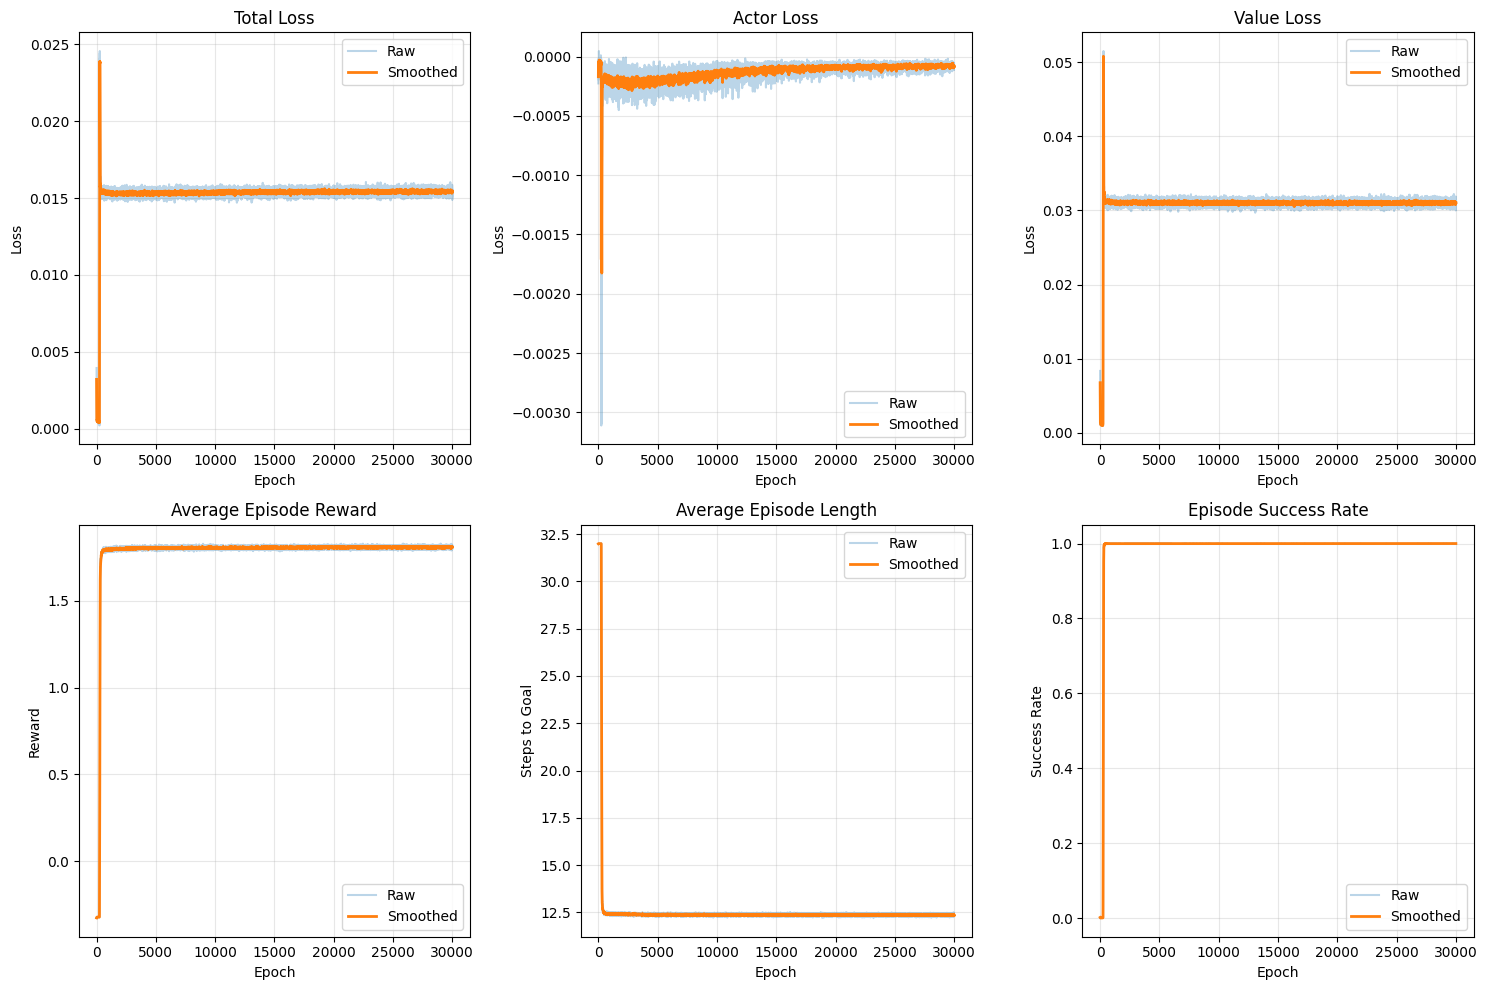

In [36]:
(carry_out, logs) = train_epoch((actor, critic, opt_actor, opt_critic, rngs),
                                jnp.arange(epochs))
final_actor, final_critic, final_opt_actor, final_opt_critic, final_rngs = carry_out
(epoch_total_losses, epoch_act_losses, epoch_value_losses, epoch_avg_rewards, 
 epoch_avg_lengths, epoch_success_rates, epoch_max_rewards, epoch_action_entropy,
 epoch_grad_norm_actor, epoch_grad_norm_critic) = logs

print("done training")
# Visualize training results
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

total_losses = np.array(epoch_total_losses)
act_losses = np.array(epoch_act_losses)
value_losses = np.array(epoch_value_losses)
avg_rewards = np.array(epoch_avg_rewards)
avg_lengths = np.array(epoch_avg_lengths)
success_rates = np.array(epoch_success_rates)
action_entropies = np.array(epoch_action_entropy)
max_rewards = np.array(epoch_max_rewards)
grad_norm_actor_arr = np.array(epoch_grad_norm_actor)
grad_norm_critic_arr = np.array(epoch_grad_norm_critic)

total_losses = total_losses.mean(axis=1)
act_losses = act_losses.mean(axis=1)
value_losses = value_losses.mean(axis=1)
def smooth_curve(data, window_size=10):
    if len(data) < window_size:
        window_size = max(1, len(data) // 2)
    return uniform_filter1d(data, size=window_size, mode='nearest')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].plot(total_losses, alpha=0.3, label='Raw')
axes[0, 0].plot(smooth_curve(total_losses), label='Smoothed', linewidth=2)
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(act_losses, alpha=0.3, label='Raw')
axes[0, 1].plot(smooth_curve(act_losses), label='Smoothed', linewidth=2)
axes[0, 1].set_title('Actor Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[0, 2].plot(value_losses, alpha=0.3, label='Raw')
axes[0, 2].plot(smooth_curve(value_losses), label='Smoothed', linewidth=2)
axes[0, 2].set_title('Value Loss')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend()

axes[1, 0].plot(avg_rewards, alpha=0.3, label='Raw')
axes[1, 0].plot(smooth_curve(avg_rewards), label='Smoothed', linewidth=2)
axes[1, 0].set_title('Average Episode Reward')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Reward')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(avg_lengths, alpha=0.3, label='Raw')
axes[1, 1].plot(smooth_curve(avg_lengths), label='Smoothed', linewidth=2)
axes[1, 1].set_title('Average Episode Length')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Steps to Goal')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

axes[1, 2].plot(success_rates, alpha=0.3, label='Raw')
axes[1, 2].plot(smooth_curve(success_rates), label='Smoothed', linewidth=2)
axes[1, 2].set_title('Episode Success Rate')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Success Rate')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

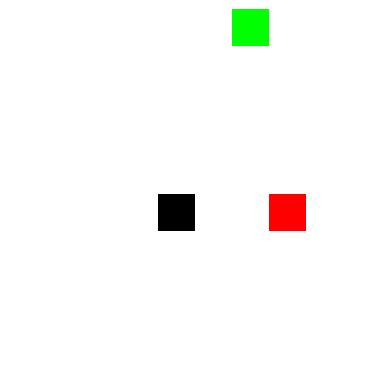

In [39]:

B = 4
T = 64
rngs = nnx.Rngs(3)
epoch_key = rngs()
keys = jax.random.split(epoch_key, B)
init_states = batched_init(keys)

@nnx.scan(in_axes=(nnx.Carry, 0), out_axes=(nnx.Carry, 0))
def roll(carry, _):
    policy, rngs, states = carry
    obs_t = batched_get_grid(states)                                   
    logits_t = policy(obs_t.reshape(obs_t.shape[0], -1).astype(jnp.float32))
    actions = jnp.argmax(logits_t, axis=-1)
    next_states, (_, rew, done) = batched_step(states, actions)
    return (policy, rngs, next_states), (states, actions, rew, done)

(_, (cum_states, cum_actions, cum_rew, cum_done)) = roll((final_actor, rngs, init_states),
                                                         jnp.arange(T))
import numpy as np
render_B  = jax.vmap(env.render, in_axes=0)
render_TB = jax.vmap(render_B, in_axes=0)
frames_tb = np.asarray(render_TB(cum_states))

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
fps = 8
fig, ax = plt.subplots()
im = ax.imshow(frames_tb[0, 0])   # first frame of episode 0
ax.axis('off')

def update(i):
    im.set_data(frames_tb[i, 0])
    return (im,)

ani = animation.FuncAnimation(fig, update, frames=frames_tb.shape[0],
                              interval=1000/fps, blit=True)
HTML(ani.to_jshtml())   # inline, no file writing
